<a href="https://colab.research.google.com/github/qazakhi515/ai_foundation/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch

In [2]:
import torch

In [3]:
print(torch.__version__)

2.11.0+cu128


In [5]:
print('CUDA available:', torch.cuda.is_available())

CUDA available: True


In [23]:
scalar = torch.tensor(5)
print('scalar:', scalar)
print('scalar:', scalar.size())

scalar: tensor(5)
scalar: torch.Size([])


In [22]:
vector = torch.tensor([1, 2, 3])
print('vector:', vector)
print('vector:', vector.shape)
print("dimension:",vector.ndim)
print('size:',scalar.size())

vector: tensor([1, 2, 3])
vector: torch.Size([3])
dimension: 1
size: torch.Size([])


In [25]:
MATRIX = torch.tensor([[1, 2, 3],[4, 5, 6]])
print('matrix:', MATRIX.ndim)
print('shape:',MATRIX.shape)

matrix: 2
shape: torch.Size([2, 3])


In [29]:
tesnor3d = torch.tensor([[[1, 2, 3]
                       ,[4, 5, 6]],
                        [[4, 5, 6],
                         [1, 2, 4]]]) #3d
print('matrix:',MATRIX)
print('shape:',tesnor3d.shape) # [2, 2, 3]  1 - '2' buyerda 2ta matrisa bor degani , 2-'2' row qatorlarni bildiradi. 3- '3' bu column lar qancha ekanligini bildiradi.
print('DIMENSION:',tesnor3d.ndim)

matrix: tensor([[[1, 2, 3],
         [4, 5, 6]],

        [[4, 5, 6],
         [1, 2, 4]]])
shape: torch.Size([2, 2, 3])
DIMENSION: 3


In [30]:
random_numbers = torch.rand(2, 3)  # values between 0 and 1

print('Random Numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Device of random_numbers:', random_numbers.device)

Random Numbers: tensor([[0.1304, 0.2055, 0.1092],
        [0.7702, 0.5587, 0.1467]])
Data type: torch.float32
Device of random_numbers: cpu


In [31]:
print('Zeros:', torch.zeros(3, 3))

Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [32]:
print('Ones:', torch.ones(2, 4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [33]:
x = torch.tensor([[1, 2],
                  [3, 4]])

y = torch.tensor([[5, 6],
                  [7, 8]])

# Element-wise addition
print('Addition:', x + y)
print('================')

# Element-wise multiplication
print('Multiplication:', x * y)
print('================')

# Matrix multiplication
print('Matrix @ multiplication:', x @ y)

Addition: tensor([[ 6,  8],
        [10, 12]])
Multiplication: tensor([[ 5, 12],
        [21, 32]])
Matrix @ multiplication: tensor([[19, 22],
        [43, 50]])


[1, 2] * [5, 7] = 1*5 + 2*7 = 19


In [34]:
# Import PyTorch and matplotlib
import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cu128'

In [35]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [36]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [37]:
# Create weight and bias
weight = 0.7
bias = 0.3

# Create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

print("X:", X)

print("\n y:", y)

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
 

(40, 40, 10, 10)

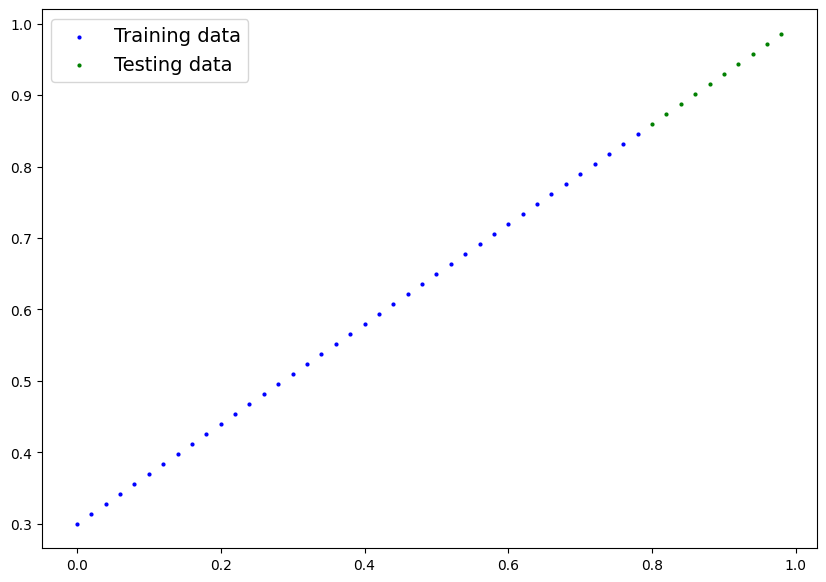

In [38]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    plt.legend(prop={"size": 14})

# Call
plot_predictions()

In [39]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )

    # Define the forward computation
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Set the manual seed when creating the model
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Linear regression da bias tushunchasi bu x= input w= weight b-bias y= natija  bias bu offset doimiy siljish. **natija qayerdan boshlanishi.**

In [40]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.01
)

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

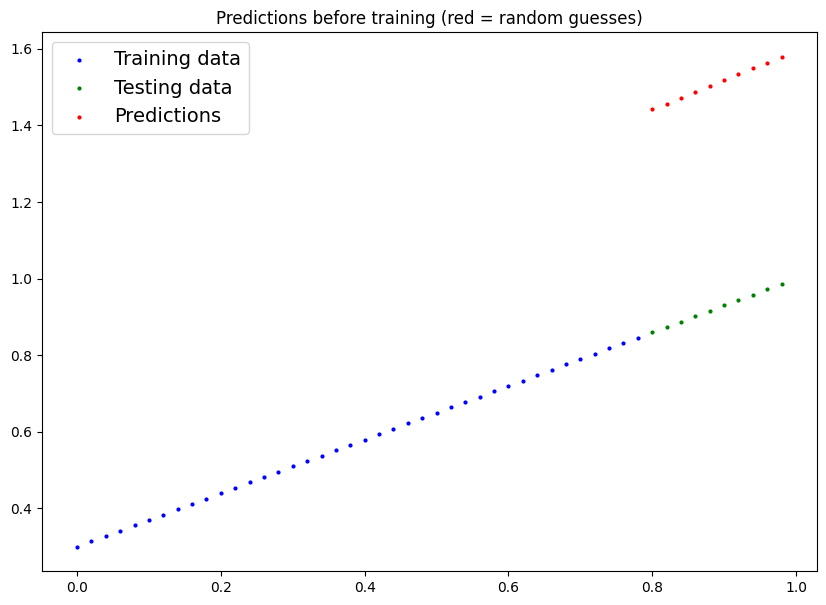

In [41]:
# See model's untrained predictions (on test set)

model_1.eval()

with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)

plt.title("Predictions before training (red = random guesses)")

In [53]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):

    ### Training
    model_1.train()  # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradient optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)

    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.1412408947944641 | Test loss: 0.2947484850883484
Epoch: 100 | Train loss: 0.14088062942028046 | Test loss: 0.30308493971824646
Epoch: 200 | Train loss: 0.14063173532485962 | Test loss: 0.31016552448272705
Epoch: 300 | Train loss: 0.14044523239135742 | Test loss: 0.3162948191165924
Epoch: 400 | Train loss: 0.14030680060386658 | Test loss: 0.32124367356300354
Epoch: 500 | Train loss: 0.14022064208984375 | Test loss: 0.3254404366016388
Epoch: 600 | Train loss: 0.14015670120716095 | Test loss: 0.32942265272140503
Epoch: 700 | Train loss: 0.14010080695152283 | Test loss: 0.3324333131313324
Epoch: 800 | Train loss: 0.1400555819272995 | Test loss: 0.3354237377643585
Epoch: 900 | Train loss: 0.140024796128273 | Test loss: 0.3377244770526886


In [50]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]], device='cuda:0')

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

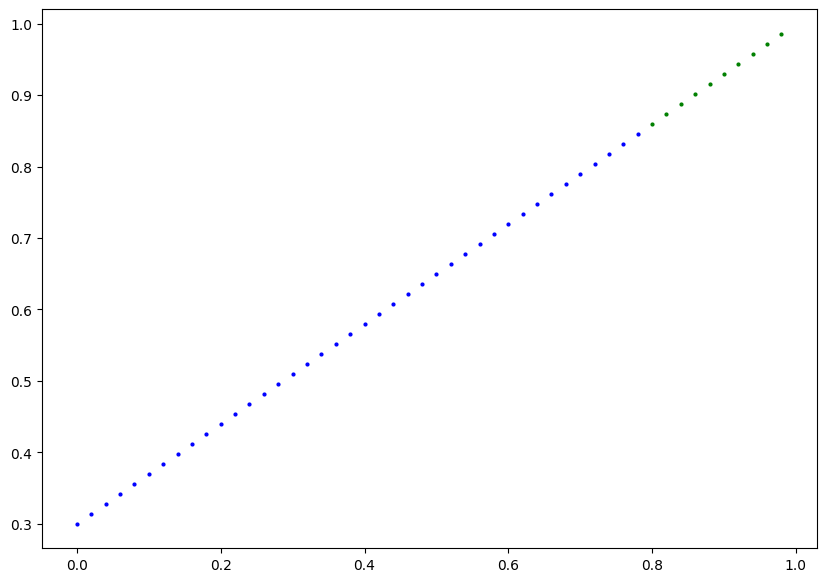

In [54]:
plot_predictions(predictions=y_preds)

In [56]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [57]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)